In [2]:
using NCDatasets, Plots, Dates, Downloads

# Load the datafiles


In [3]:
# Load the NetCDF files from the specified directory
data_dir = "datafiles" # Directory to store downloaded NetCDF files
pat = r"^chesapeake_salinity_(\d{8})_t(\d{2})z_n(\d{3})\.nc$" # Regular expression pattern to match the desired NetCDF files
files = filter(f -> occursin(pat, f), readdir(data_dir)) # Filter files in the data directory that match the pattern

# Check if any files were found
if isempty(files)
    error("No files found matching chesapeake_salinity_YYYYMMDD_tCCz_nFFF.nc")
end

# Sort the files based on the date and time extracted from the filename
frames = NamedTuple[]
for f in files
    m = match(pat, f)
    ymd = m.captures[1]
    cyc = parse(Int, m.captures[2])   # cycle hour
    fh  = parse(Int, m.captures[3])   # forecast/nowcast hour
    dt = DateTime(ymd, dateformat"yyyymmdd") + Hour(cyc) + Hour(fh)
    push!(frames, (file="$data_dir/$f", dt=dt))
end
sort!(frames, by = x -> x.dt)

"""
Load surface salinity data from a NetCDF file.

Arguments:
- file: Path to the NetCDF file

Returns:
- lon_valid: Valid longitude values
- lat_valid: Valid latitude values
- salt_valid: Valid salinity values
"""
function load_surface_salinity(file)
    # Open the NetCDF file
    ds = NCDataset(file)

    # Extract latitude, longitude, and surface salinity data
    lon = ds["lon_rho"][:]
    lat = ds["lat_rho"][:]
    salt = ds["salt"][:,:,end,1]
    
    # Close the file
    close(ds)

    # Filter out invalid data (missing values, NaNs, and values greater than 100)
    valid_idx = .!ismissing.(salt) .&& .!isnan.(salt) .&& (salt .< 100)

    # Extract valid longitude, latitude, and salinity values
    if size(lon) == size(valid_idx) && size(lat) == size(valid_idx)
        lon_valid = lon[valid_idx]
        lat_valid = lat[valid_idx]
    elseif ndims(lon) == 1 && length(lon) == length(vec(valid_idx))
        lon2 = reshape(lon, size(valid_idx))
        lat2 = reshape(lat, size(valid_idx))
        lon_valid = lon2[valid_idx]
        lat_valid = lat2[valid_idx]
    else
        lon_valid = vec(lon)[vec(valid_idx)]
        lat_valid = vec(lat)[vec(valid_idx)]
    end

    return lon_valid, lat_valid, Float64.(salt[valid_idx])
end

load_surface_salinity

# Animate the full dataset

In [4]:
anim = @animate for fr in frames
    lon_valid, lat_valid, salt_valid = load_surface_salinity(fr.file)

    scatter(
        lon_valid, lat_valid,
        marker_z = salt_valid,          # <- use marker_z for scalar coloring
        m = (1.8, :square, stroke(0)),
        c = :viridis,
        clims = (0, 35),
        colorbar = true,                # <- force colorbar on
        colorbar_title = "Salinity (PSU)",
        title = "Chesapeake Bay Surface Salinity\n$(Dates.format(fr.dt, dateformat"yyyy-mm-dd HH:MM")) UTC",
        xlabel = "Longitude",
        ylabel = "Latitude",
        legend = false,
        size = (600, 800),
        framestyle = :box,
        grid = true
    )
end
mp4(anim, "chesapeake_salinity_animation.mp4", fps = 6) # To save the file as a video

[ Info: Saved animation to c:\Users\elija\Documents\scientific-data-models\chesapeake_bay_salinity\chesapeake_salinity_animation.mp4


Plots.AnimatedGif("c:\\Users\\elija\\Documents\\scientific-data-models\\chesapeake_bay_salinity\\chesapeake_salinity_animation.mp4")

# Animate a subset of the data (in a geographic bounding box)

[ Info: Saved animation to c:\Users\elija\Documents\scientific-data-models\chesapeake_bay_salinity\tmp.gif


Plots.AnimatedGif("c:\\Users\\elija\\Documents\\scientific-data-models\\chesapeake_bay_salinity\\tmp.gif")
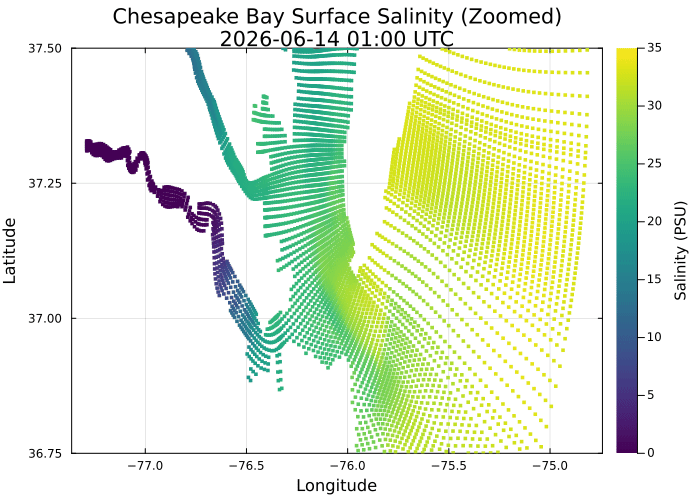

In [ ]:
lat_min, lat_max = 36.75, 37.5

# Generate the gif. The @gif macro is used to create an animation, and the mp4 function is used to save it as a video file.
anim_zoom = @gif for fr in frames
    lon_valid, lat_valid, salt_valid = load_surface_salinity(fr.file)

    roi = (lat_valid .>= lat_min) .& (lat_valid .<= lat_max)

    good_lons = lon_valid[roi]
    good_lats = lon_valid[roi]
    good_sals = salt_valid[roi]

    if any(roi)
        scatter(
            lon_valid[roi], lat_valid[roi],
            marker_z = salt_valid[roi],
            m = (1.8, :square, stroke(0)),
            c = :viridis,
            clims = (0, 35),
            colorbar = true,
            colorbar_title = "Salinity (PSU)",
            title = "Chesapeake Bay Surface Salinity (Zoomed)\n$(Dates.format(fr.dt, dateformat"yyyy-mm-dd HH:MM")) UTC",
            xlabel = "Longitude",
            ylabel = "Latitude",
            ylims = (lat_min, lat_max),
            legend = false,
            size = (700, 500),
            framestyle = :box,
            grid = true
        )
    else
        plot(
            title = "No ocean points in ROI\n$(Dates.format(fr.dt, dateformat"yyyy-mm-dd HH:MM")) UTC",
            xlabel = "Longitude",
            ylabel = "Latitude",
            ylims = (lat_min, lat_max),
            legend = false,
            size = (700, 500),
            framestyle = :box,
            grid = true
        )
    end
end

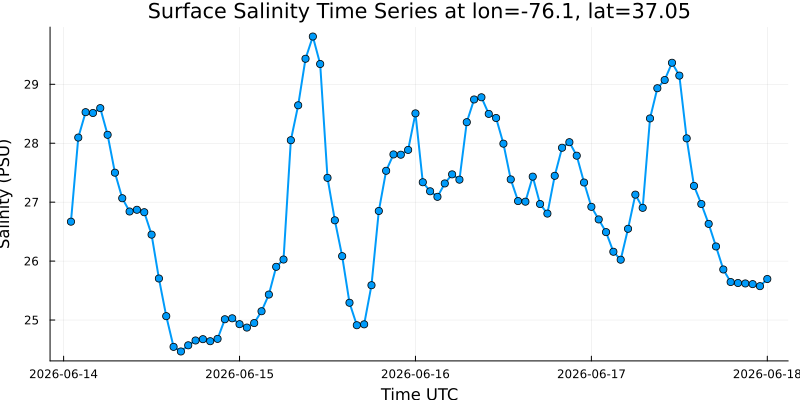

In [9]:
# Choose the location for the time series
lon_loc, lat_loc = -76.1, 37.05

function grid_lonlat(lon, lat, dims)
    if size(lon) == dims && size(lat) == dims
        return lon, lat
    elseif ndims(lon) == 1 && length(lon) == dims[2] && ndims(lat) == 1 && length(lat) == dims[1]
        lon2 = repeat(reshape(lon, (1, dims[2])), dims[1], 1)
        lat2 = repeat(reshape(lat, (dims[1], 1)), 1, dims[2])
        return lon2, lat2
    else
        return reshape(lon, dims), reshape(lat, dims)
    end
end

times = DateTime[]
salinity_ts = Float64[]

for fr in frames
    ds = NCDataset(fr.file)
    lon = ds["lon_rho"][:]
    lat = ds["lat_rho"][:]
    salt = ds["salt"][:,:,end,1]
    close(ds)

    lon2, lat2 = grid_lonlat(lon, lat, size(salt))
    valid = .!ismissing.(salt) .&& .!isnan.(salt) .&& (salt .< 100)
    if any(valid)
        dist2 = (lon2 .- lon_loc).^2 .+ (lat2 .- lat_loc).^2
        dist2 .= ifelse.(valid, dist2, Inf)
        idx = argmin(dist2)
        push!(times, fr.dt)
        push!(salinity_ts, float(salt[idx]))
    end
end

plot(
    times, salinity_ts,
    marker = :circle,
    line = (:solid, 2),
    title = "Surface Salinity Time Series at lon=$lon_loc, lat=$lat_loc",
    xlabel = "Time UTC",
    ylabel = "Salinity (PSU)",
    legend = false,
    grid = true,
    size = (800, 400)
)